In [1]:
import pandas as pd
import datetime as dt


In [2]:
def to_datetime(input_string):
    return dt.datetime.strptime(input_string, "%Y-%m-%d %H:%M:%S")

In [4]:
Y_df = pd.read_csv("full_dataset.csv")
timestamps = Y_df['ds']
new_timestamps = timestamps.apply(to_datetime)
Y_df['ds'] = new_timestamps
print(len(Y_df))
Y_df.head()


84275


,Unnamed: 0,ds,y,unique_id
0,149,2027-05-20 00:01:32,134,540_05_20
1,150,2027-05-20 00:06:32,133,540_05_20
2,151,2027-05-20 00:11:32,132,540_05_20
3,152,2027-05-20 00:16:32,131,540_05_20
4,153,2027-05-20 00:21:32,130,540_05_20


In [4]:
uids = Y_df['unique_id'].unique()
Y_df = Y_df.query('unique_id in @uids').reset_index(drop=True)

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\statsforecast\core.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


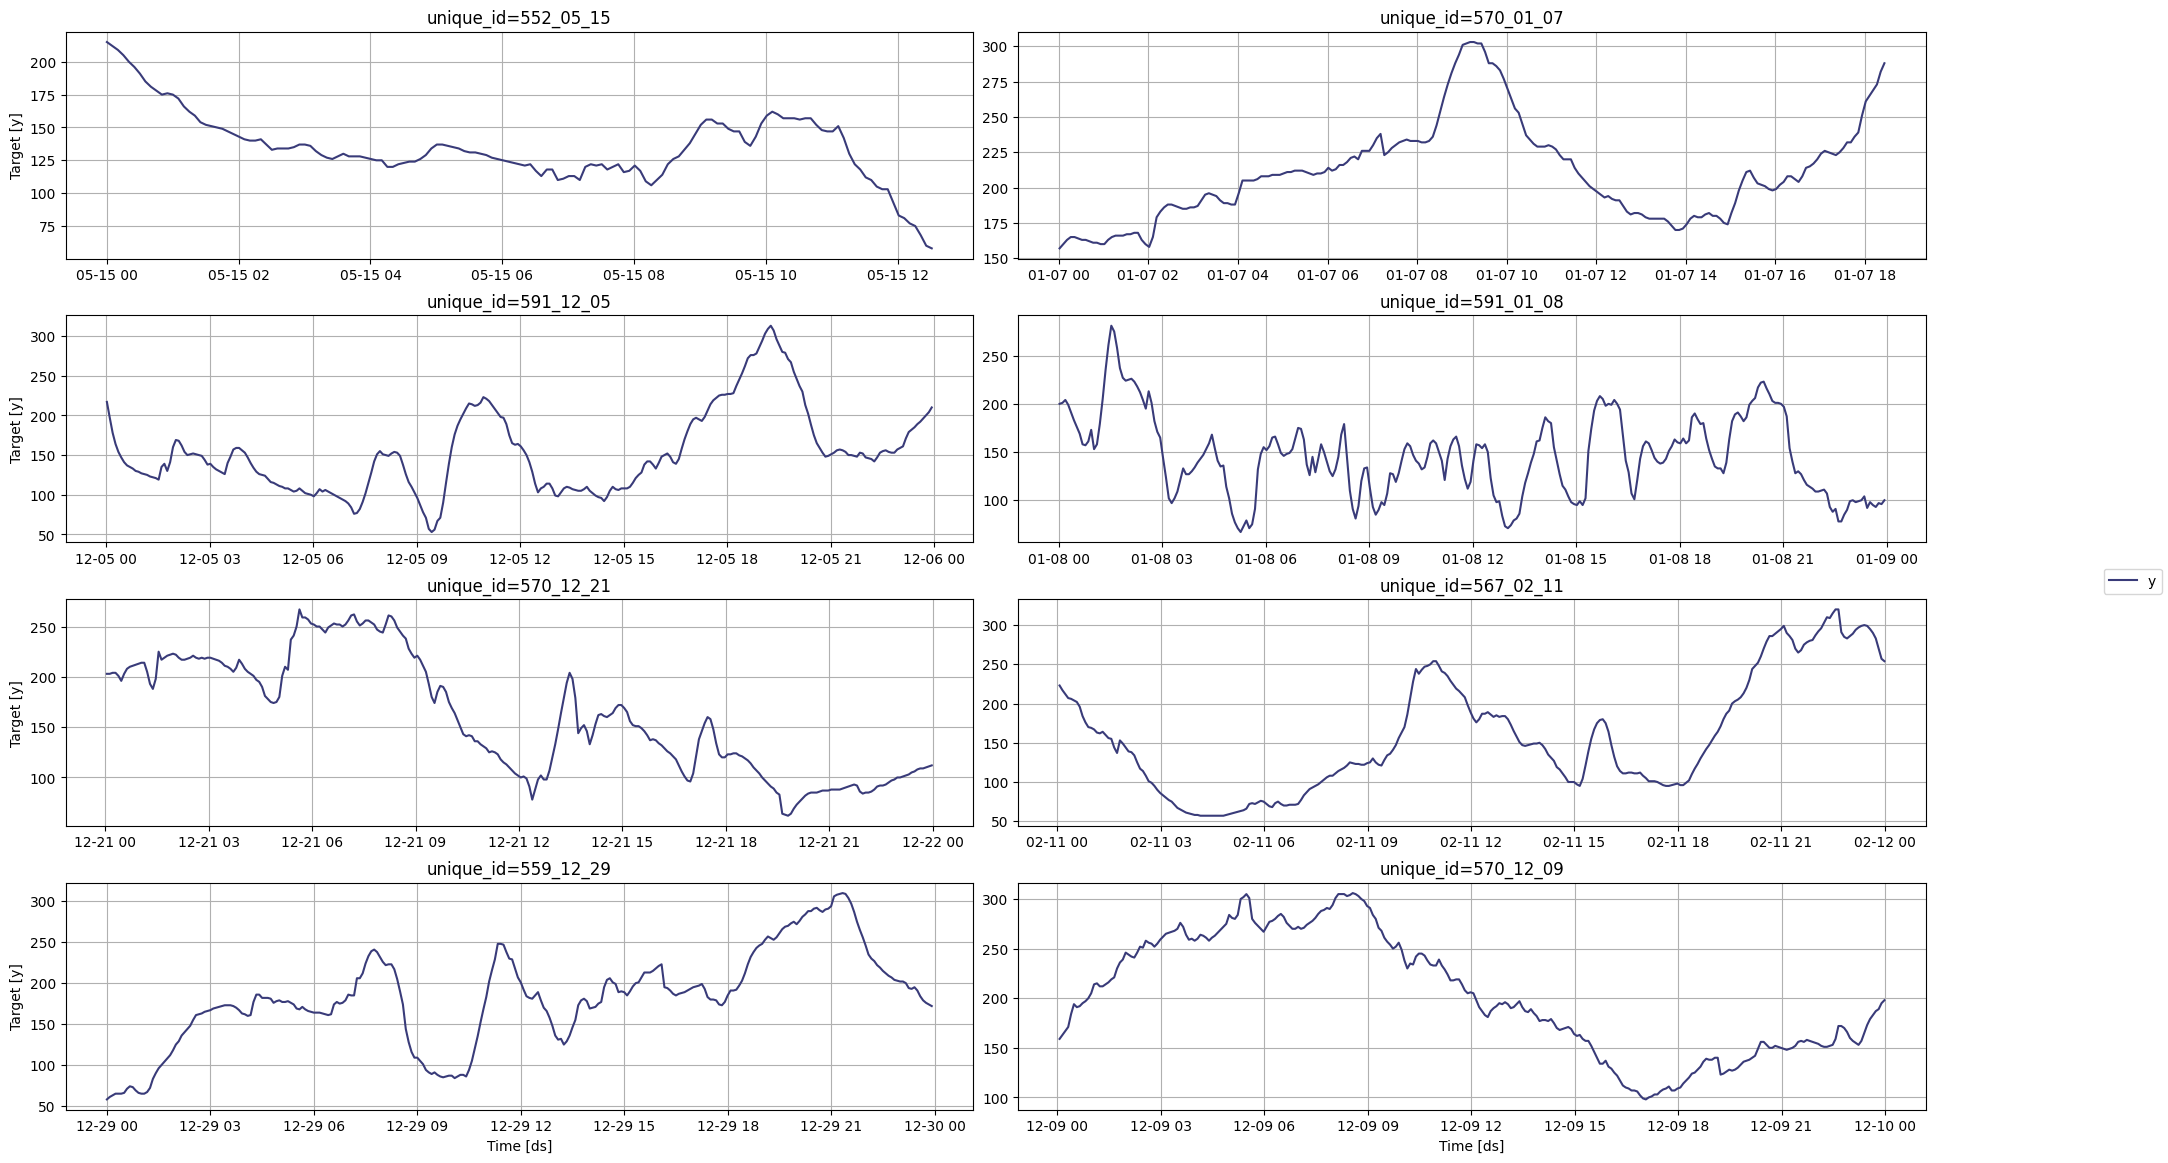

In [6]:
from statsforecast import StatsForecast
StatsForecast.plot(Y_df, engine='matplotlib')

In [11]:
from ray import tune

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS, AutoLSTM, AutoTimesNet
from neuralforecast.models import NHITS, TimesNet
from neuralforecast.losses.pytorch import MQLoss

In [31]:
config_nhits = {
    "input_size": tune.choice([25, 35, 50]),              # Length of input window
    "start_padding_enabled": True,
    "n_blocks": 5*[1],                                              # Length of input window
    "mlp_units": 5 * [[64, 64]],                                  # Length of input window
    "n_pool_kernel_size": tune.choice([5*[1], 5*[2], 5*[4],         
                                      [8, 4, 2, 1, 1]]),            # MaxPooling Kernel size
    "n_freq_downsample": tune.choice([[8, 4, 2, 1, 1],
                                      [1, 1, 1, 1, 1]]),            # Interpolation expressivity ratios
    "learning_rate": tune.loguniform(1e-4, 1e-2),                   # Initial Learning rate
    "scaler_type": tune.choice([None]),                             # Scaler type
    "max_steps": tune.choice([5]),                               # Max number of training iterations
    "batch_size": tune.choice([1, 4, 10]),                          # Number of series in batch
    "windows_batch_size": tune.choice([128, 256, 512]),             # Number of windows in batch
    "random_seed": tune.randint(1, 20),                             # Random seed
}

config_lstm = {
    "input_size": tune.choice([48, 48*2, 48*3]),              # Length of input window
    "encoder_hidden_size": tune.choice([64, 128]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([500, 1000]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 4]),                        # Number of series in batch
    "random_seed": tune.randint(1, 20),                       # Random seed
}

config_TimesNet = {
    "input_size": tune.choice([48, 48*2, 48*3]),              # Length of input window
    "encoder_hidden_size": tune.choice([64, 128]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([500, 1000]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 4]),                        # Number of series in batch
    "random_seed": tune.randint(1, 20),                       # Random seed
}

nf = NeuralForecast(
    models=[
        NHITS(h=180, input_size=50, max_steps=5),
        AutoNHITS(h=180, config=config_nhits, loss=MQLoss(), num_samples=5),
        # AutoLSTM(h=3, config=config_lstm, loss=MQLoss(), num_samples=2),
        # AutoTimesNet(h=48, config=config_TimesNet, loss=MQLoss(), num_samples=5)
    ],
    freq='min'
)

Seed set to 1


In [15]:
nf.fit(df=Y_df)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Exception: Time series is too short for training, consider setting a smaller input size or set start_padding_enabled=True

In [ ]:
fcst_df = nf.predict()
fcst_df.columns = fcst_df.columns.str.replace('-median', '')
fcst_df.head()

In [ ]:
StatsForecast.plot(Y_df, fcst_df, engine='matplotlib', max_insample_length=48, level=[80, 90])

In [ ]:
# Plot to unique_ids and some selected models
StatsForecast.plot(Y_df, fcst_df, models=["AutoLSTM"], unique_ids=["H107", "H104"], level=[80, 90], engine='matplotlib', )

In [6]:
freq = 'h' # h or min
horizon = 3 if freq=='h' else 90
nf = NeuralForecast(
    models=[
        NHITS(h=horizon, input_size=50, max_steps=5),
        TimesNet(h=horizon, input_size=50, max_steps=5),
        # AutoNHITS(h=horizon, config=config_nhits, loss=MQLoss(), num_samples=5)
        # AutoLSTM(h=3, config=config_lstm, loss=MQLoss(), num_samples=2),
        # AutoTimesNet(h=48, config=config_TimesNet, loss=MQLoss(), num_samples=5)
    ],
    freq=freq
)

Seed set to 1
Seed set to 1


In [7]:
cv_df = nf.cross_validation(Y_df, n_windows=1)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

In [8]:
cv_df.columns = cv_df.columns.str.replace('-median', '')
cv_df.head()


,unique_id,ds,cutoff,NHITS,TimesNet,Unnamed: 0,y
0,540_05_20,2027-05-20 21:56:36,2027-05-20 20:56:36,94.806793,105.127808,412.0,57.0
1,540_05_20,2027-05-20 22:56:36,2027-05-20 20:56:36,105.638466,102.965492,424.0,99.0
2,540_05_20,2027-05-20 23:56:36,2027-05-20 20:56:36,99.368935,89.498886,436.0,119.0
3,540_05_21,2027-05-21 21:56:40,2027-05-21 20:56:40,153.617081,138.559647,700.0,76.0
4,540_05_21,2027-05-21 22:56:40,2027-05-21 20:56:40,166.698318,107.862610,712.0,116.0


In [9]:
for cutoff in cv_df['cutoff'].unique():
    a = cv_df.query('cutoff == @cutoff').drop(columns=['y', 'cutoff', 'Unnamed: 0']), 
    break

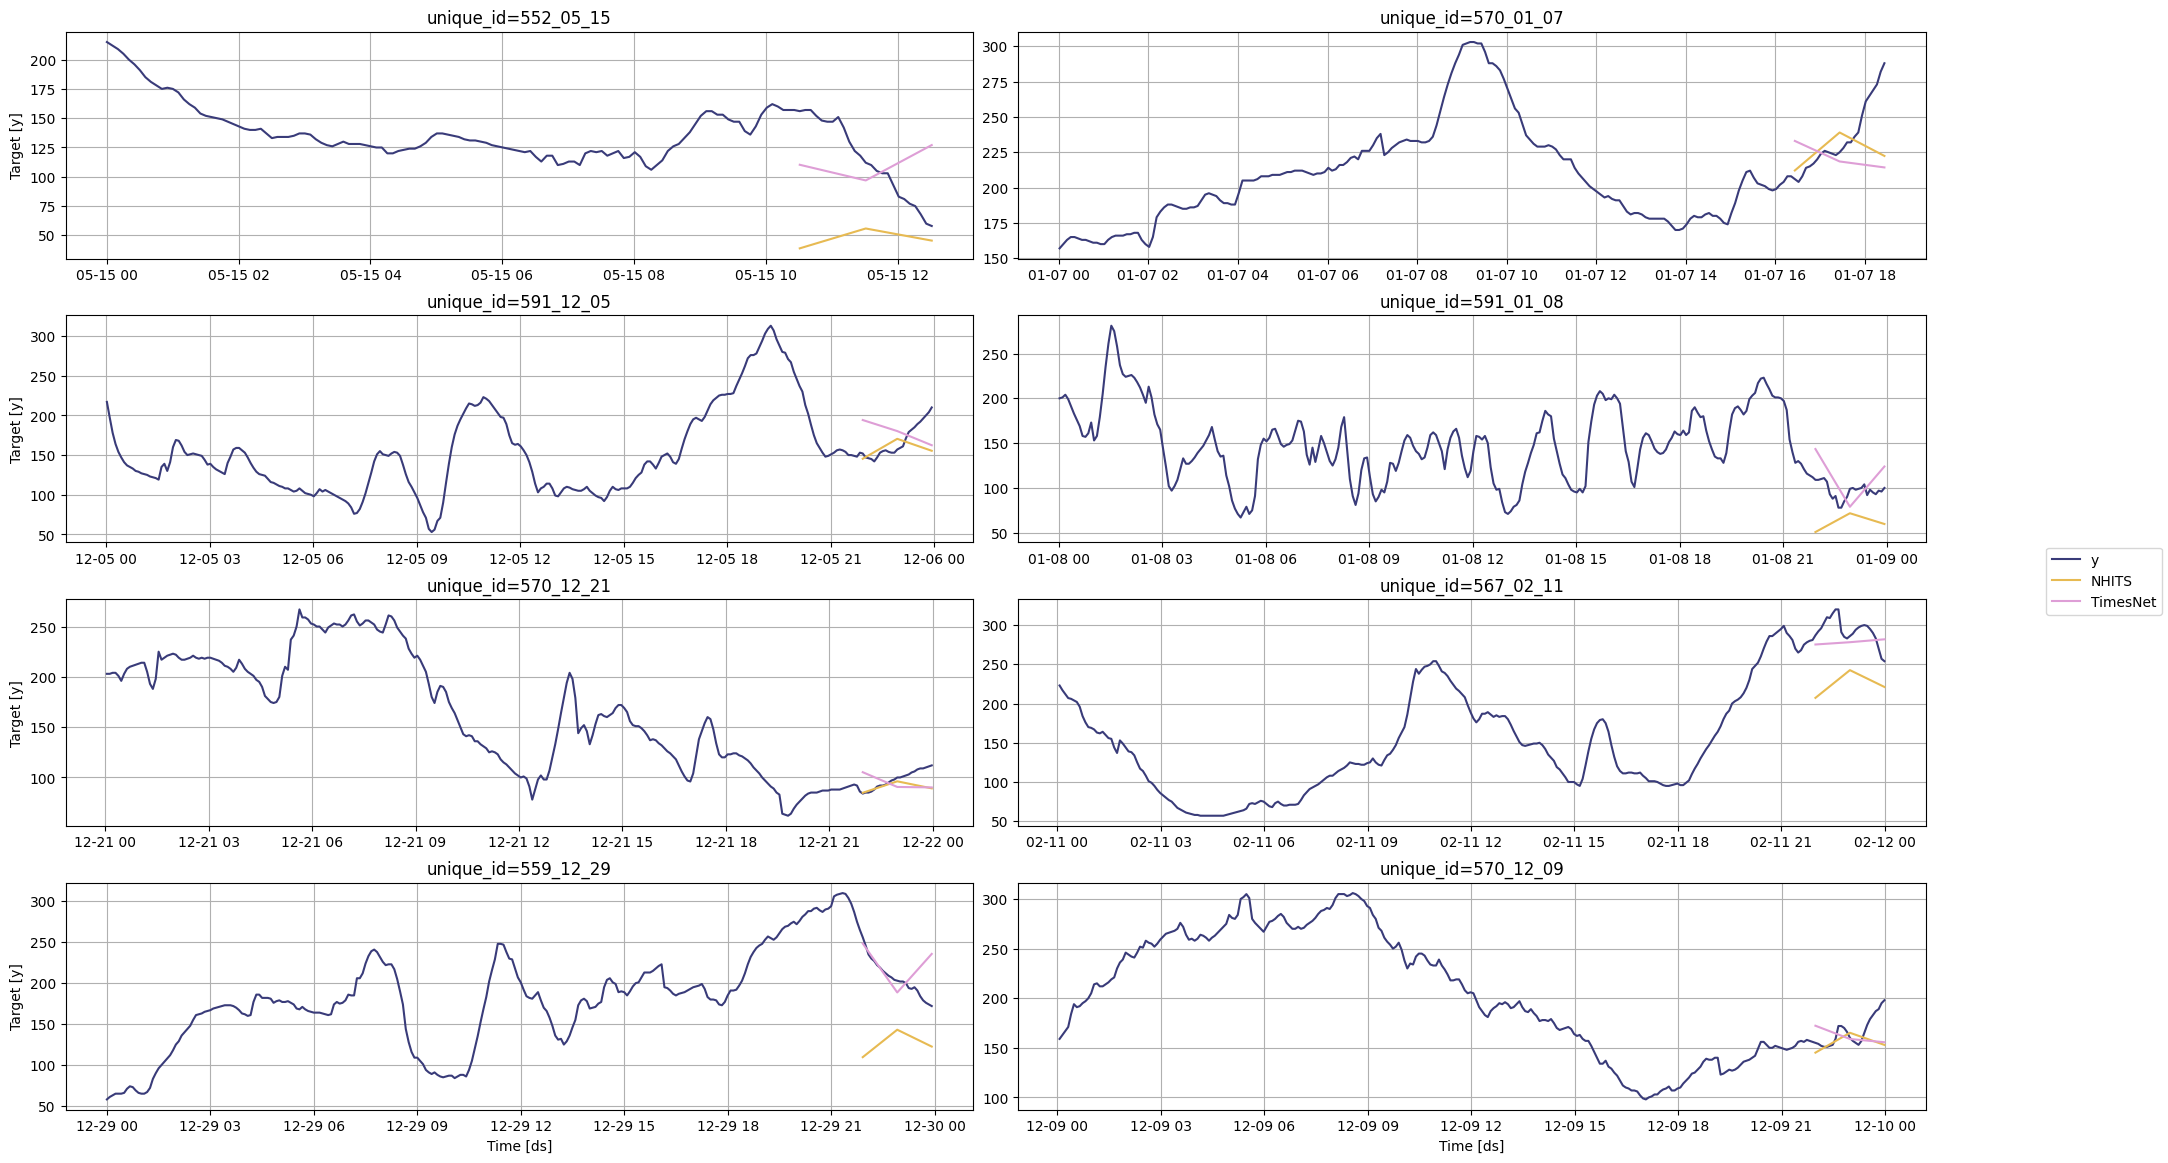

In [12]:
StatsForecast.plot(Y_df, cv_df.drop(columns=['y', 'cutoff', 'Unnamed: 0']), max_insample_length=1260, engine='matplotlib')

In [18]:
for cutoff in cv_df['cutoff'].unique():
    StatsForecast.plot(
        Y_df, 
        cv_df.query("cutoff == @cutoff").drop(columns=['y', 'cutoff', 'Unnamed: 0']),
        max_insample_length=1260,
        unique_ids=['540_05_20'],
        engine='matplotlib'
    )